# Prophet
Implementación del modelo Prophet de Meta para los cinco activos financieros.
Se comparan los resultados contra ARIMA para establecer el techo de rendimiento de los modelos clásicos antes de pasar a arquitecturas deep learning.

# Importación de librerias y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Ruta relativa al notebook
ruta = Path.cwd().parent / "data"

# Cargar datos procesados
activos = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]
datos = {}

for activo in activos:
    df = pd.read_csv(ruta / f"../data/{activo}_processed.csv", index_col=0, parse_dates=True)
    datos[activo] = df
    print(f"{activo.upper()}: {len(df)} registros cargados")

Importing plotly failed. Interactive plots will not work.


EURUSD: 2134 registros cargados
GBPUSD: 2134 registros cargados
USDJPY: 2135 registros cargados
BTC: 2995 registros cargados
ETH: 2995 registros cargados


# Preparación y ejecución de Prophet

In [2]:
# Prophet sobre todos los activos
resultados_prophet = []

for activo in activos:
    print(f"\nProcesando {activo.upper()}...")
    
    df = datos[activo].copy()
    retornos = df["Retorno"].dropna()
    regimen = df["Regimen"].dropna()
    
    # Split 80/20
    split = int(len(retornos) * 0.8)
    train = retornos.iloc[:split]
    test = retornos.iloc[split:]
    regimen_test = regimen.iloc[split:].reindex(test.index)
    
    # Transformación de los datos al formato de Prophet: columnas ds e y
    df_prophet = pd.DataFrame({
        "ds": train.index,
        "y": train.values
    })
    
    # Entrenar Prophet
    modelo = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
    modelo.fit(df_prophet)
    
    # Predecir sobre el periodo test
    futuro = pd.DataFrame({"ds": test.index})
    forecast = modelo.predict(futuro)
    predicciones = forecast["yhat"].values
    
    # Métricas globales
    mae = mean_absolute_error(test.values, predicciones)
    rmse = np.sqrt(mean_squared_error(test.values, predicciones))
    
    resultado = {
        "Activo": activo.upper(),
        "MAE_global": round(mae, 6),
        "RMSE_global": round(rmse, 6),
        "MAE_baja_vol": None,
        "MAE_alta_vol": None,
    }
    
    # Métricas por régimen
    for reg_val, reg_nombre in [("Baja", "baja_vol"), ("Alta", "alta_vol")]:
        mask = regimen_test == reg_val
        if mask.sum() > 0:
            mae_r = mean_absolute_error(test.values[mask], predicciones[mask])
            resultado[f"MAE_{reg_nombre}"] = round(mae_r, 6)
    
    resultados_prophet.append(resultado)
    print(f" MAE: {mae:.6f} | MAE baja: {resultado['MAE_baja_vol']} | MAE alta: {resultado['MAE_alta_vol']}")
   
# Tabla resumen
df_prophet_res = pd.DataFrame(resultados_prophet)
print("\n\nRESUMEN PROPHET - TODOS LOS ACTIVOS")
print("=" * 70)
print(df_prophet_res.to_string(index=False))
   
# Guardar
df_prophet_res.to_csv("../results/prophet_resultados.csv", index=False)
print("\nGuardado en la carpeta resultados/prophet_resultados.csv")
    


Procesando EURUSD...


10:42:37 - cmdstanpy - INFO - Chain [1] start processing
10:42:37 - cmdstanpy - INFO - Chain [1] done processing
10:42:37 - cmdstanpy - INFO - Chain [1] start processing
10:42:37 - cmdstanpy - INFO - Chain [1] done processing


 MAE: 0.003465 | MAE baja: 0.002935 | MAE alta: 0.004344

Procesando GBPUSD...


10:42:37 - cmdstanpy - INFO - Chain [1] start processing


 MAE: 0.003540 | MAE baja: 0.003393 | MAE alta: 0.004742

Procesando USDJPY...


...

 MAE: 0.004976 | MAE baja: 0.003731 | MAE alta: 0.005813

Procesando BTC...


10:42:38 - cmdstanpy - INFO - Chain [1] done processing
10:42:38 - cmdstanpy - INFO - Chain [1] start processing


 MAE: 0.017641 | MAE baja: 0.016116 | MAE alta: 0.026649

Procesando ETH...


10:42:38 - cmdstanpy - INFO - Chain [1] done processing


 MAE: 0.027143 | MAE baja: 0.025075 | MAE alta: 0.033373


RESUMEN PROPHET - TODOS LOS ACTIVOS
Activo  MAE_global  RMSE_global  MAE_baja_vol  MAE_alta_vol
EURUSD    0.003465     0.004739      0.002935      0.004344
GBPUSD    0.003540     0.004586      0.003393      0.004742
USDJPY    0.004976     0.006499      0.003731      0.005813
   BTC    0.017641     0.025077      0.016116      0.026649
   ETH    0.027143     0.038729      0.025075      0.033373

Guardado en la carpeta resultados/prophet_resultados.csv


## Resultados Prophet
Prophet obtiene métricas muy similares a ARIMA en todos los activos. El patrón se mantiene: cripto presenta MAE 5-8x superior al Forex, y la alta volatilidad incrementa el error en ambos tipos de activo.

# Comparativa ARIMA vs Prophet

In [3]:
df_arima = pd.read_csv("../results/arima_resultados.csv")

comparativa = pd.DataFrame({
    "Activo": df_prophet_res["Activo"],
    "ARIMA_MAE": df_arima["MAE_global"].values,
    "Prophet_MAE": df_prophet_res["MAE_global"].values,
    "ARIMA_MAE_baja": df_arima["MAE_baja_vol"].values,
    "Prophet_MAE_baja": df_prophet_res["MAE_baja_vol"].values,
    "ARIMA_MAE_alta": df_arima["MAE_alta_vol"].values,
    "Prophet_MAE_alta": df_prophet_res["MAE_alta_vol"].values,
    "Mejor_global": ["ARIMA" if a < p else "Prophet"
                     for a, p in zip(df_arima["MAE_global"], df_prophet_res["MAE_global"])]
})

print("COMPARATIVA ARIMA vs PROPHET")
print("=" * 80)
print(comparativa.to_string(index=False))

comparativa.to_csv("../results/comparativa_arima_prophet.csv", index=False)
print("\nGuardado en results/comparativa_arima_prophet.csv")

COMPARATIVA ARIMA vs PROPHET
Activo  ARIMA_MAE  Prophet_MAE  ARIMA_MAE_baja  Prophet_MAE_baja  ARIMA_MAE_alta  Prophet_MAE_alta Mejor_global
EURUSD   0.003458     0.003465        0.002928          0.002935        0.004339          0.004344        ARIMA
GBPUSD   0.003538     0.003540        0.003390          0.003393        0.004753          0.004742        ARIMA
USDJPY   0.004960     0.004976        0.003739          0.003731        0.005787          0.005813        ARIMA
   BTC   0.017535     0.017641        0.016022          0.016116        0.026445          0.026649        ARIMA
   ETH   0.027212     0.027143        0.025180          0.025075        0.033258          0.033373      Prophet

Guardado en results/comparativa_arima_prophet.csv


La tabla nos indica que los modelos Prophet y ARIMA tienen un rendimiento prácticamente idéntico en todos los activos. Este resultado es lógico porque ambos modelos son esencialmente lineales y cuando el orden óptimo de ARIMA es (0, 0, 0), Prophet tampoco encuentra estructura para explotar. 

La columna "Mejor_global" nos indica que hay un empate entre ambos modelos. Esto nos indica que necesitamos modelos más avanzados, por lo que probaremos con LSTM y TFT. 

# Visualización comparativa

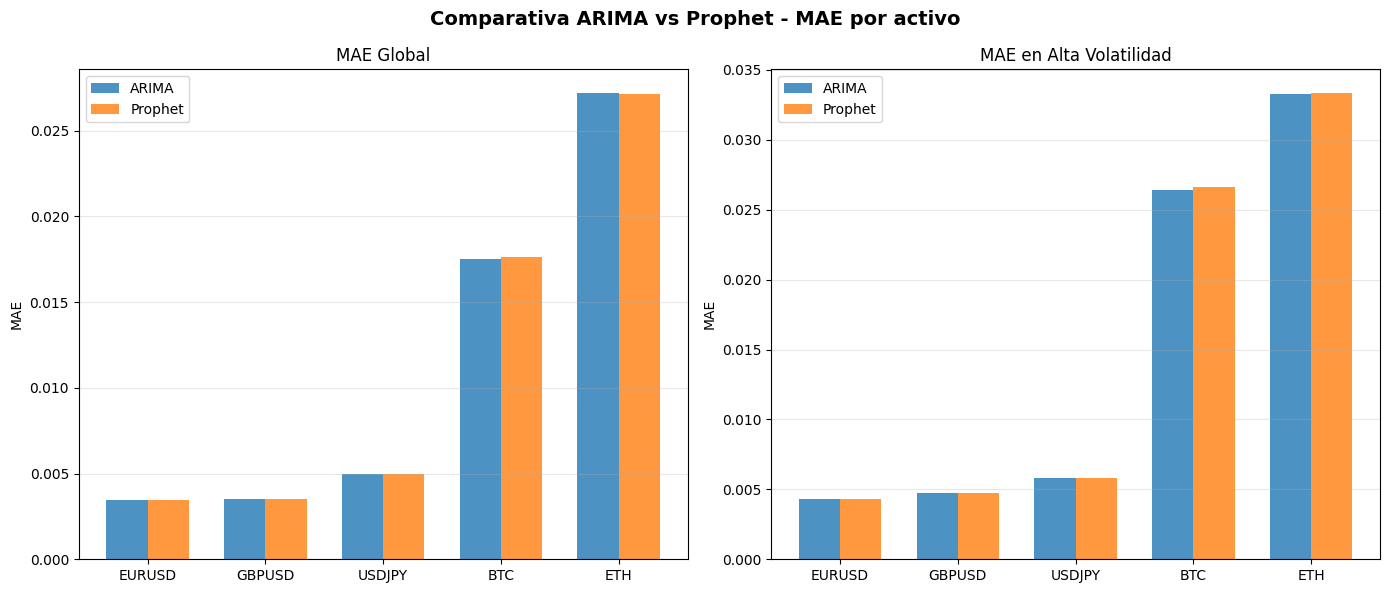

Gráfico guardado en la carpeta results


In [4]:
# Visualización comparativa ARIMA vs Prophet
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparativa ARIMA vs Prophet - MAE por activo", fontsize=14, fontweight="bold")

x = np.arange(len(comparativa["Activo"]))
width = 0.35

# MAE global
axes[0].bar(x - width/2, comparativa["ARIMA_MAE"], width, label="ARIMA", color="#1f77b4", alpha=0.8)
axes[0].bar(x + width/2, comparativa["Prophet_MAE"], width, label="Prophet",color="#ff7f0e", alpha=0.8)
axes[0].set_title("MAE Global")
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparativa["Activo"])
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# MAE alta volatilidad
axes[1].bar(x - width/2, comparativa["ARIMA_MAE_alta"], width, label="ARIMA", color="#1f77b4", alpha=0.8)
axes[1].bar(x + width/2, comparativa["Prophet_MAE_alta"], width, label="Prophet", color="#ff7f0e", alpha=0.8)
axes[1].set_title("MAE en Alta Volatilidad")
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparativa["Activo"])
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../results/04_comparativa_arima_prophet.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

## Conclusiones:
- ARIMA y PROPHET son prácticamente idénticos. Ninguno de los dos modelos encuentra ventaja sobre el
otro, lo que confirma que ambos tienen el mismo techo de rendimiento para series financieras.
- La brecha cripto vs Forex es enorme y visual: las barras de BTC y ETH son 5-8 veces las que representan a las divisas.
- En alta volatilidad el patrón se mantiene, aquí se refleja que en periodos turbulentos la diferencia se amplia entre divisas y cripto.